## Importing Laibraries 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder , StandardScaler
from imblearn.over_sampling import SMOTE 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier , RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV , StratifiedKFold


## Load the Dataset 

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Data Handling 

In [4]:
df.drop(columns=['id'] , inplace=True)


In [5]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [7]:
df.describe(include= ['object' , 'int'])

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke
count,5110,5110.000000,5110.000000,5110,5110,5110,5110,5110.000000
unique,3,NaN,NaN,2,5,2,4,NaN
top,Female,NaN,NaN,Yes,Private,Urban,never smoked,NaN
freq,2994,NaN,NaN,3353,2925,2596,1892,NaN
mean,NaN,0.097456,0.054012,NaN,NaN,NaN,NaN,0.048728
std,NaN,0.296607,0.226063,NaN,NaN,NaN,NaN,0.215320
min,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
50%,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
75%,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000


In [8]:
df.describe(include=['float'])

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


In [9]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [11]:
df.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

## Handel Outliers

#### Numeric Features 

In [12]:
cat_features = df.select_dtypes(['object' , 'int']).columns
print(cat_features)

num_features = df.select_dtypes(['float']).columns 
num_features

Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'stroke'],
      dtype='object')


Index(['age', 'avg_glucose_level', 'bmi'], dtype='object')

<Axes: >

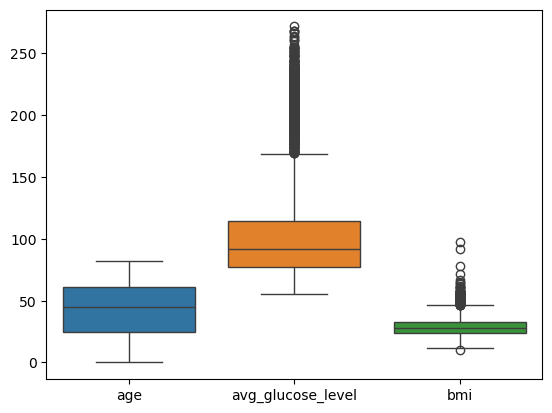

In [13]:
sns.boxplot(df[num_features])

In [14]:
def bmi_to_cat(value):
    if value < 18.5:
        return 'UnderWeight'
    
    if value < 25:
        return 'Normal'
    
    if value < 30:
        return 'OverWeight'
    
    if value < 35:
        return 'Obese'
    
    return 'ExtremelyObese'

def glucose_to_cat(value):
    if value < 60:
        return 'VeryLow'
    
    if value < 80:
        return 'Low'
    
    if value < 120:
        return 'Normal'
    
    if value < 180:
        return 'High'

    return 'VeryHigh'

In [15]:
df['bmi_cat'] = df['bmi'].apply(bmi_to_cat)
df['glucose_cat'] = df['avg_glucose_level'].apply(glucose_to_cat)
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_cat,glucose_cat
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,ExtremelyObese,VeryHigh
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,OverWeight,VeryHigh
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Obese,Normal
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Obese,High
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Normal,High
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,OverWeight,VeryHigh
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,OverWeight,Low
7,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,Normal,Normal
8,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,Unknown,1,OverWeight,Low
9,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1,Normal,VeryLow


In [16]:
df['glucose_cat'].unique()

array(['VeryHigh', 'Normal', 'High', 'Low', 'VeryLow'], dtype=object)

In [17]:
df.drop(columns=['avg_glucose_level' , 'bmi'] , inplace=True)

In [18]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke,bmi_cat,glucose_cat
0,Male,67.0,0,1,Yes,Private,Urban,formerly smoked,1,ExtremelyObese,VeryHigh
1,Female,61.0,0,0,Yes,Self-employed,Rural,never smoked,1,OverWeight,VeryHigh
2,Male,80.0,0,1,Yes,Private,Rural,never smoked,1,Obese,Normal
3,Female,49.0,0,0,Yes,Private,Urban,smokes,1,Obese,High
4,Female,79.0,1,0,Yes,Self-employed,Rural,never smoked,1,Normal,High


### Categorical features 

In [19]:
cat_features = df.select_dtypes(include= ['object' , 'int']).columns
cat_features

Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'stroke', 'bmi_cat', 'glucose_cat'],
      dtype='object')

In [20]:
df['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [21]:
for feat in cat_features:
    print(f'{df[feat].value_counts()} , \n')

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64 , 

hypertension
0    4612
1     498
Name: count, dtype: int64 , 

heart_disease
0    4834
1     276
Name: count, dtype: int64 , 

ever_married
Yes    3353
No     1757
Name: count, dtype: int64 , 

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64 , 

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64 , 

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64 , 

stroke
0    4861
1     249
Name: count, dtype: int64 , 

bmi_cat
OverWeight        1610
Normal            1243
Obese             1000
ExtremelyObese     920
UnderWeight        337
Name: count, dtype: int64 , 

glucose_cat
Normal      2461
Low         1310
VeryHigh     583
High         536
VeryLow      220
Name: count, dtype: int64 , 



In [22]:
df.drop(df[df['gender']=='Other'].index , inplace=True )

In [23]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

In [24]:
df.loc[df['smoking_status'] == 'Unknown' , 'smoking_status' ] = df['smoking_status'].mode()[0]
df['smoking_status'].value_counts()

smoking_status
never smoked       3436
formerly smoked     884
smokes              789
Name: count, dtype: int64

## Splitting the Data into Train & Test 

In [25]:
x = df.drop(columns=['stroke'])
y=df['stroke']
x

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,bmi_cat,glucose_cat
0,Male,67.0,0,1,Yes,Private,Urban,formerly smoked,ExtremelyObese,VeryHigh
1,Female,61.0,0,0,Yes,Self-employed,Rural,never smoked,OverWeight,VeryHigh
2,Male,80.0,0,1,Yes,Private,Rural,never smoked,Obese,Normal
3,Female,49.0,0,0,Yes,Private,Urban,smokes,Obese,High
4,Female,79.0,1,0,Yes,Self-employed,Rural,never smoked,Normal,High
...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,never smoked,OverWeight,Normal
5106,Female,81.0,0,0,Yes,Self-employed,Urban,never smoked,ExtremelyObese,High
5107,Female,35.0,0,0,Yes,Self-employed,Rural,never smoked,Obese,Normal
5108,Male,51.0,0,0,Yes,Private,Rural,formerly smoked,OverWeight,High


In [26]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=.2 , random_state=42 , stratify=y)

In [27]:
x_train.shape, y_train.shape , x_test.shape  , y_test.shape

((4087, 10), (4087,), (1022, 10), (1022,))

## Scaling and Encoding with transformer 

In [28]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder , StandardScaler

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          5109 non-null   object 
 1   age             5109 non-null   float64
 2   hypertension    5109 non-null   int64  
 3   heart_disease   5109 non-null   int64  
 4   ever_married    5109 non-null   object 
 5   work_type       5109 non-null   object 
 6   Residence_type  5109 non-null   object 
 7   smoking_status  5109 non-null   object 
 8   stroke          5109 non-null   int64  
 9   bmi_cat         5109 non-null   object 
 10  glucose_cat     5109 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 479.0+ KB


In [30]:
cat_features

Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'stroke', 'bmi_cat', 'glucose_cat'],
      dtype='object')

In [31]:
for cat in cat_features:
    print(f'{cat} {df[cat].unique()} , \n')

gender ['Male' 'Female'] , 

hypertension [0 1] , 

heart_disease [1 0] , 

ever_married ['Yes' 'No'] , 

work_type ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked'] , 

Residence_type ['Urban' 'Rural'] , 

smoking_status ['formerly smoked' 'never smoked' 'smokes'] , 

stroke [1 0] , 

bmi_cat ['ExtremelyObese' 'OverWeight' 'Obese' 'Normal' 'UnderWeight'] , 

glucose_cat ['VeryHigh' 'Normal' 'High' 'Low' 'VeryLow'] , 



In [32]:
num_features = df.select_dtypes(include= ["float"]).columns
nominal_features = ['gender' , 'hypertension' , 'heart_disease' , 'ever_married' , 'work_type' , 'Residence_type']

ordinal_features= {
    'smoking_status' : ['never smoked' , 'formerly smoked' , 'smokes'],
    'bmi_cat' : ['UnderWeight' ,'Normal', 'OverWeight' ,  'Obese' , 'ExtremelyObese' ],
    'glucose_cat' : ['VeryLow' ,'Low','Normal' , 'High' , 'VeryHigh' ]

}

In [33]:
transformer = ColumnTransformer(
    transformers= [ 
        ('num' , StandardScaler() , num_features),
        ('one' , OneHotEncoder(sparse_output=False , drop= 'if_binary') , nominal_features),
        ('ord' , OrdinalEncoder(categories=list(ordinal_features.values())) , list(ordinal_features.keys()))
    ]
)

In [34]:
x_train_trans = transformer.fit_transform(x_train)
x_test_trans = transformer.transform(x_test)

## Imbalance Handling 

In [35]:
y_train.value_counts()

stroke
0    3888
1     199
Name: count, dtype: int64

In [36]:
smote = SMOTE(sampling_strategy=.5)

x_train_resampled , y_train_resampled = smote.fit_resample(x_train_trans , y_train)

In [37]:
y_train_resampled.value_counts()

stroke
0    3888
1    1944
Name: count, dtype: int64

## Model Selection 

In [38]:
models={
    'LogisticRegression':LogisticRegression() ,
    'KNeighborsClassifier': KNeighborsClassifier() ,
    'SVC': SVC(probability=True) ,
    'DecisionTreeClassifier': DecisionTreeClassifier() ,
    'RandomForestClassifier' : RandomForestClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier() ,
    'XGBClassifier': XGBClassifier()
}

params_grid = {
    'LogisticRegression' : {
        'C' : [ .1 , 1 , 100]
    },

    'KNeighborsClassifier':{
        'n_neighbors': [3, 5, 7]
    },

    'SVC' : {
        'kernel': ['linear', 'rbf', 'poly'],
        'C' : [1, 10, 100]
    }, 
    'DecisionTreeClassifier' : {
        'max_depth': [3, 5, 10, None],
        'criterion': ['gini', 'entropy']
    },

    'RandomForestClassifier': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None]
    },

    'AdaBoostClassifier': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    },

    'XGBClassifier' : {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

In [39]:
score_results = {}
best_params = {}
for name , model in models.items():
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params_grid[name],
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='f1_weighted',
        n_jobs=-1
    )

    grid_search.fit(x_train_resampled , y_train_resampled)

    score_results[name] = grid_search.best_score_
    best_params[name] = grid_search.best_params_

    print(f'{name} : {grid_search.best_params_} \n Best Score : {float(grid_search.best_score_):.4f}')
    print(50*'=')

LogisticRegression : {'C': 0.1} 
 Best Score : 0.7660
KNeighborsClassifier : {'n_neighbors': 3} 
 Best Score : 0.9062
SVC : {'C': 100, 'kernel': 'rbf'} 
 Best Score : 0.9108
DecisionTreeClassifier : {'criterion': 'gini', 'max_depth': None} 
 Best Score : 0.9032
RandomForestClassifier : {'max_depth': None, 'n_estimators': 100} 
 Best Score : 0.9535
AdaBoostClassifier : {'learning_rate': 1.0, 'n_estimators': 200} 
 Best Score : 0.9092
XGBClassifier : {'learning_rate': 0.1, 'n_estimators': 200} 
 Best Score : 0.9561


In [40]:
score_results


{'LogisticRegression': np.float64(0.7660337990837253),
 'KNeighborsClassifier': np.float64(0.9062260725598936),
 'SVC': np.float64(0.9108335343943634),
 'DecisionTreeClassifier': np.float64(0.9032151527398389),
 'RandomForestClassifier': np.float64(0.9534553777008657),
 'AdaBoostClassifier': np.float64(0.9091727527982505),
 'XGBClassifier': np.float64(0.956061013316772)}

In [41]:
best_params

{'LogisticRegression': {'C': 0.1},
 'KNeighborsClassifier': {'n_neighbors': 3},
 'SVC': {'C': 100, 'kernel': 'rbf'},
 'DecisionTreeClassifier': {'criterion': 'gini', 'max_depth': None},
 'RandomForestClassifier': {'max_depth': None, 'n_estimators': 100},
 'AdaBoostClassifier': {'learning_rate': 1.0, 'n_estimators': 200},
 'XGBClassifier': {'learning_rate': 0.1, 'n_estimators': 200}}

In [42]:
best_3_names = sorted(score_results, key=score_results.get, reverse=True)[:3]
best_3_names 


['XGBClassifier', 'RandomForestClassifier', 'SVC']

## Build the model 

In [43]:
best_XGBClassifier = XGBClassifier(learning_rate=0.2, n_estimators= 100)
best_RandomForestClassifier = RandomForestClassifier(max_depth= None, n_estimators= 200)
best_DecisionTreeClassifier = DecisionTreeClassifier(criterion= 'entropy', max_depth= None) 

In [44]:
best_3_models = [ ('XGBClassifier' , best_XGBClassifier) ,
('RandomForestClassifier' , best_RandomForestClassifier),
('DecisionTreeClassifier' , best_DecisionTreeClassifier)]

In [45]:
from sklearn.ensemble import VotingClassifier

classifier = VotingClassifier(best_3_models, voting='soft')

classifier.fit(x_train_resampled, y_train_resampled)

,estimators,"[('XGBClassifier', ...), ('RandomForestClassifier', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
pipeline = Pipeline(
    steps=[
        ('transformer' , transformer), 
        ('model' , classifier)
    ]
)

In [47]:
y_pred = pipeline.predict(x_test)
f1_score(y_test, y_pred, average='weighted')

0.9198489817129547

## Exporting The final model 

In [48]:
import joblib 

joblib.dump(pipeline, 'pipeline.pkl')

['pipeline.pkl']

In [49]:
import sys
print(sys.executable)


c:\Users\facebook\anaconda3\python.exe
